In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
from loaders import loader_XA_to_NA
import importlib
importlib.reload(loader_XA_to_NA)
import tifffile
import SimpleITK
from loaders import stitcher_XA
from helpers import module_auxiliary as ma
from PIL import Image
import imageio.v3 as iio
Image.MAX_IMAGE_PIXELS = None 

In [2]:
path = '/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/'
pre = 'Mosaic element_'
# Ordering of the elements:
# [Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr]

images = []
image_names = [pre + 'Al.png', pre + 'Ca.png',pre + 'Cl.png', pre + 'Cr.png', pre + 'Fe.png',
                    pre + 'K.png', pre + 'Mg.png', pre + 'Na.png', pre + 'Ni.png',
                    pre + 'O.png', pre + 'P.png', pre + 'S.png', pre + 'Si.png',
                    pre + 'Ti.png', pre + 'Zr.png']
for i in image_names:
    print(path+i)
    image = iio.imread(path+i)
    image = gray = np.dot(image[..., :3], [0.2989, 0.5870, 0.1140])
    images.append(image)
#images = np.stack(images)
#images[images>150]=0
#images[0,images[0]>20]=0

/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Al.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Ca.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Cl.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Cr.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Fe.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_K.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Mg.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Na.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Ni.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_O.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_P.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_S.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Si.png
/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/Mosaic element_Ti.png
/dtu-compu

In [4]:
images = np.stack(images)

In [10]:
images = images.astype(np.uint8)

In [13]:
pre = 'eds'
new_names = [pre + 'Al.tiff', pre + 'Ca.tiff',pre + 'Cl.tiff', pre + 'Cr.tiff', pre + 'Fe.tiff',
                    pre + 'K.tiff', pre + 'Mg.tiff', pre + 'Na.tiff', pre + 'Ni.tiff',
                    pre + 'O.tiff', pre + 'P.tiff', pre + 'S.tiff', pre + 'Si.tiff',
                    pre + 'Ti.tiff', pre + 'Zr.tiff']
for i in range(len(image_names)):
    tifffile.imwrite(path + new_names[i], images[i])


Some info regarding the elemental composition of minerals is needed:
Plagioclase (Albite-Anorthite). Mg-Al-Ca (on the slides). 

Albite (NaAlSi₃O₈),  (Al is an identifyer)
Anorthite (CaAl₂Si₂O₈) (Al is an identifyer)
Orthoclase (KAlSi₃O₈) (Al is an identifyer)
Clinopyroxene (Mg2 Si2 O6) or (Ca Mg Si2 O6), (Ca is a weak identifyer)
Orthopyroxene (Mg2 Si2 O6) or (Fe2 Si2 O6) (No clear identifyer discovered)
Chlorapatite (Ca5(PO4)3 Cl) (C + Cl + P) is a clear identifyer
Chromite (Fe Cr2 O4) (Cr is a unique identifyer, and Fe is also an identifyer)
Ilminite (Fe Ti O3) (Ti is a unique identifyer)
Pyrite (Fe S2) (S is a unique identifyer)

In [5]:
#Ordering of the elements:
#[Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr]

Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr = 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
albite = [1, Ca, Cl, Cr, Fe, K, Mg, 1, Ni, 8, P, S, 3, Ti, Zr]
anorthite = [2, 1, Cl, Cr, Fe, K, Mg, Na, Ni, 8, P, S, 2, Ti, Zr]
orthoclase = [1, Ca, Cl, Cr, Fe, 1, Mg, Na, Ni, 8, P, S, 3, Ti, Zr]
clinopyroxene = [Al, 1, Cl, Cr, Fe, K, 2, Na, Ni, 6, P, S, 2, Ti, Zr]
orthopyroxene = [Al, Ca, Cl, Cr, 2, K, 2, Na, Ni, 6, P, S, 2, Ti, Zr]
chlorapatite = [Al, 5, 2, Cr, Fe, K, Mg, Na, Ni, 12, 3, S, Si, Ti, Zr]
chromite = [Al, Ca, Cl, 2, 1, K, Mg, Na, Ni, 4, P, S, Si, Ti, Zr]
ilminite = [Al, Ca, Cl, Cr, 1, K, Mg, Na, Ni, 3, P, S, Si, 1, Zr]
pyrite = [Al, Ca, Cl, Cr, 1, K, Mg, Na, Ni, O, P, 2, Si, Ti, Zr]
nothing = [Al, Ca, Cl, Cr, Fe, K, Mg, Na, Ni, O, P, S, Si, Ti, Zr]
basis = np.array([albite, anorthite, orthoclase, clinopyroxene, orthopyroxene, chlorapatite, chromite, ilminite, pyrite, nothing])


In [23]:
log_images_d = np.log(images[:,::10,::10]+0.1)
log_basis = np.log(basis+0.1)

/tmp/pbs.496589.hnode41/ipykernel_700105/3986675280.py:12: RuntimeWarning: divide by zero encountered in log
  np.log(heatmap.T), origin="lower", aspect="auto", cmap="YlGnBu",


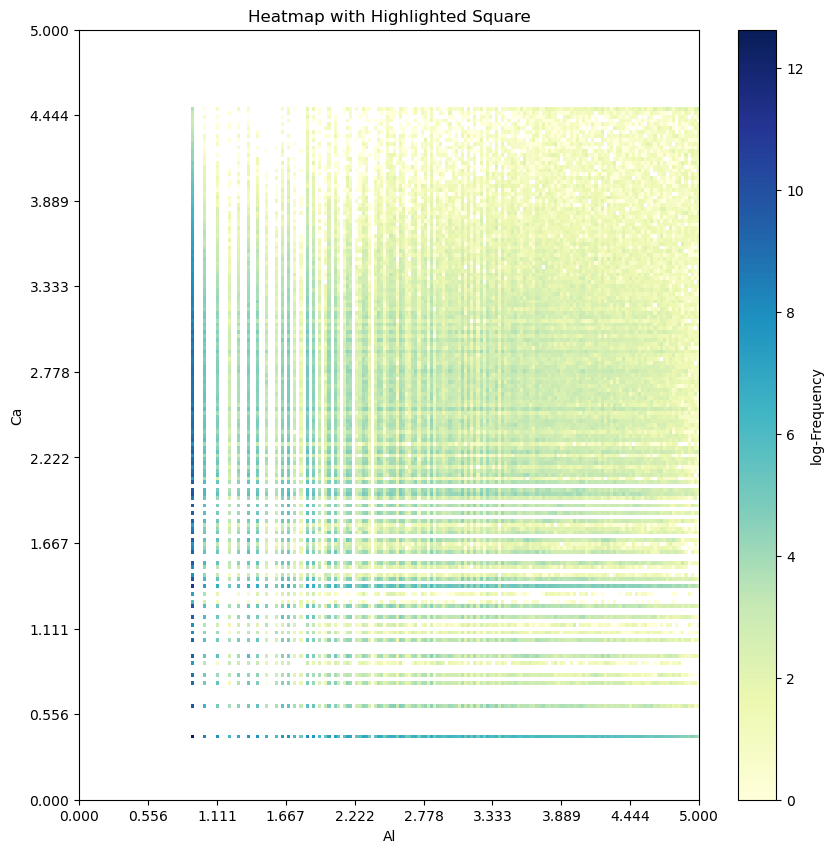

In [24]:
# Create the heatmap
nticks = 10
bins = 200
range_ = [0,5]
heatmap, xedges, yedges = np.histogram2d(
    log_images_d[2].ravel(), log_images_d[1].ravel(), bins=(bins, bins),
    range=[range_, range_]
)
# Plot the heatmap
plt.figure(figsize=(10, 10))
plt.imshow(
    np.log(heatmap.T), origin="lower", aspect="auto", cmap="YlGnBu",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]  # Set extent to match data range
)
plt.colorbar(label="log-Frequency")
plt.xlabel("Al")
plt.ylabel("Ca")
plt.title("Heatmap with Highlighted Square")

# Set custom ticks
x_tick_positions = np.linspace(xedges[0], xedges[-1], num=nticks)
y_tick_positions = np.linspace(yedges[0], yedges[-1], num=nticks)
x_tick_labels = [f"{x:.3f}" for x in x_tick_positions]
y_tick_labels = [f"{y:.3f}" for y in y_tick_positions]
plt.xticks(x_tick_positions, x_tick_labels)
plt.yticks(y_tick_positions, y_tick_labels)

# Show the plot
plt.show()

In [29]:
l, N, M = np.shape(log_images_d)
data = log_images_d.reshape(l, N*M).T
%pip install scikit-learn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Define initial centroids (e.g., picking 2 random points from the data)
initial_centroids = log_basis # Second centroid

# Perform KMeans with the specified initial centroids
kmeans = KMeans(n_clusters=10, init=initial_centroids, n_init=1)  # n_init=1 ensures only one run
kmeans.fit(data)

# Results
print("Cluster centers (after fitting):")
print(kmeans.cluster_centers_)

print("\nCluster labels:")
print(kmeans.labels_)
print(kmeans.cluster_centers_)

Note: you may need to restart the kernel to use updated packages.
Cluster centers (after fitting):
[[ 0.0827141   1.80780547  1.14738477  0.77014869  2.56346004  0.5037565
   3.4207853   3.03915227  1.16648676  3.64723906  0.84140544  1.45598695
   4.22044534  1.50334888 -0.23410224]
 [ 0.70580095  2.08183259  1.16680191  0.70991151  0.83005038  0.65892055
   1.96022711  2.37905355  1.11709792  3.45064707  0.73292812  1.42057089
   4.26256649  1.31029212 -0.29624592]
 [ 0.0674086   1.7317891   1.18007728  0.76575588  2.3963989   2.70213956
   3.26751823  1.15357545  1.16105039  3.57802868  0.82942274  1.45171275
   4.2048677   1.49856916 -0.23419922]
 [-0.11983745  2.58556293  1.04957018  0.7700968   2.52746153  0.33257377
   3.3802042   0.57100455  1.15709265  3.47458206  0.8842622   1.45240096
   4.12826734  1.4983198  -0.24060814]
 [-0.22301887  0.84247102  1.07172086  0.79173622  2.69881091  0.33478719
   3.4501462   0.57636725  1.15509048  3.54017017  0.7658076   1.45111583
   4.0

In [26]:
log_images_d_labels= kmeans.labels_.T.reshape(N, M)

In [ ]:
temp = kmeans.labels_
fig, axes = plt.subplots(2, 5, figsize=(25, 10))  # 1 row, 3 columns
fig.patch.set_facecolor('black')  # Set the background color to black

for i in range(10):
    i_x = i//2
    i_y = i%2

    im0 = axes[i_y,i_x].imshow(log_images_d_labels==i,cmap='gray')
    axes[i_y,i_x].axis('off')

In [114]:
print(data[1100000])
print(log_images_d[:,1100000//M,1100000%M])

[0.86204572 1.58060625 4.39787907 0.96698385 2.98723124 2.80385117
 3.41279652 2.51431981 1.20836315 4.15885183 0.97516323 1.51371965
 3.91342203 1.37265172 0.37569295]
[0.86204572 1.58060625 4.39787907 0.96698385 2.98723124 2.80385117
 3.41279652 2.51431981 1.20836315 4.15885183 0.97516323 1.51371965
 3.91342203 1.37265172 0.37569295]


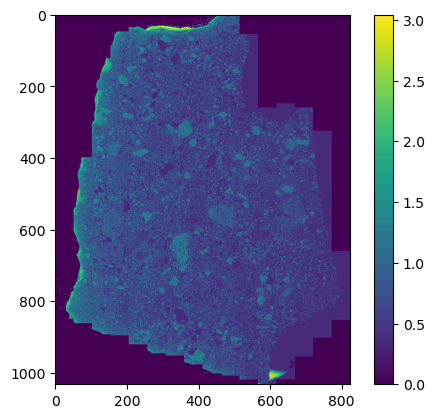

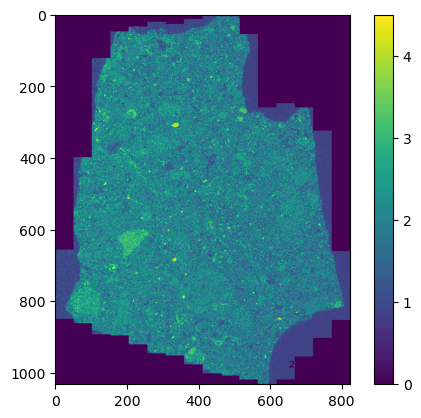

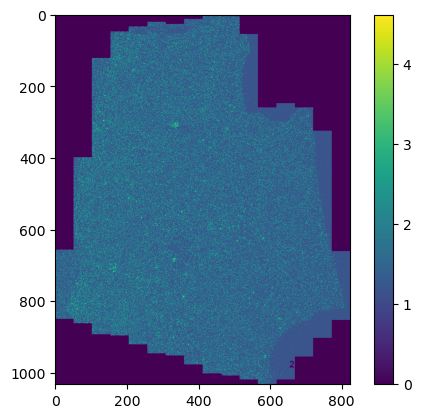

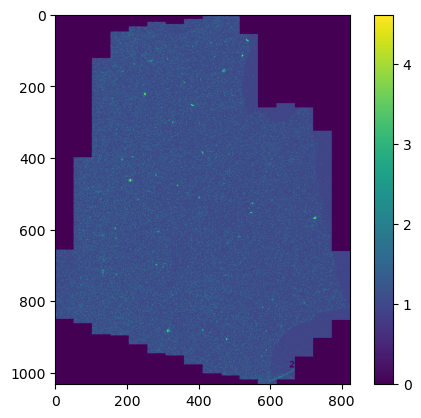

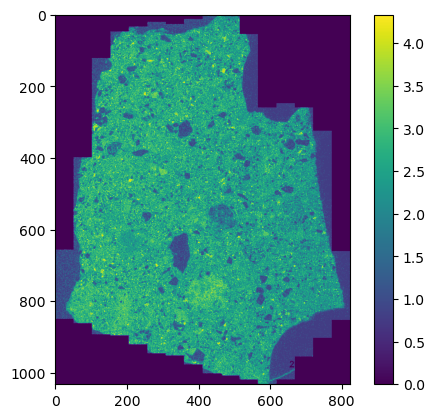

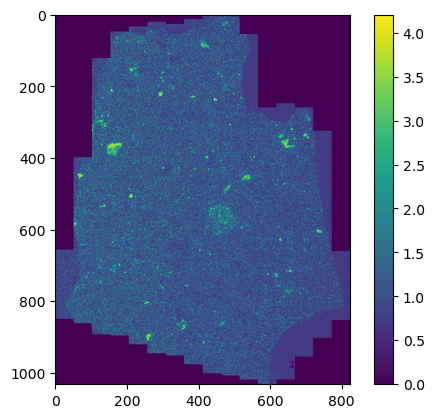

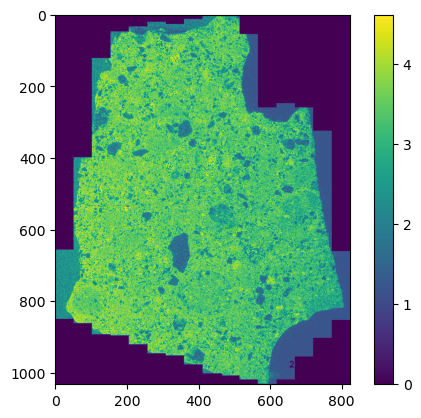

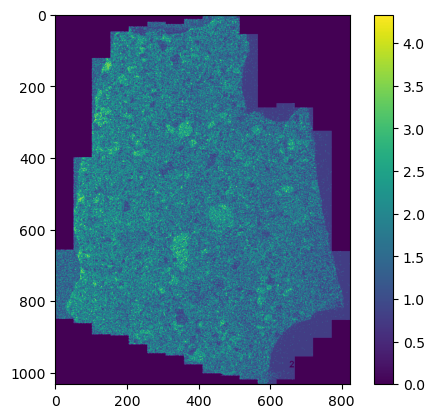

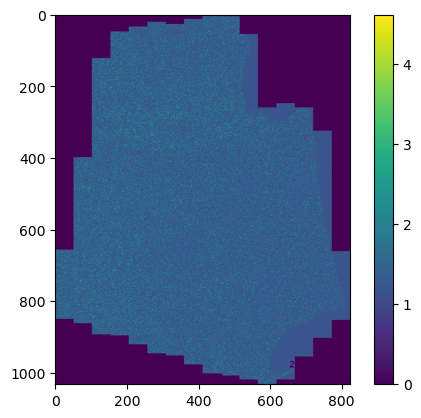

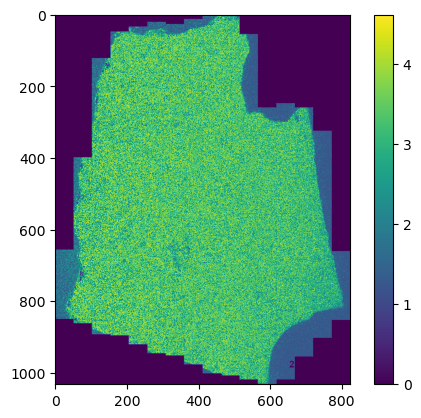

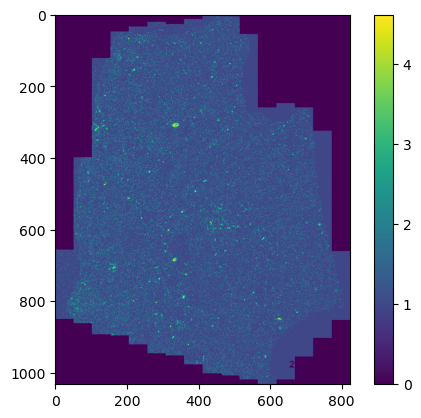

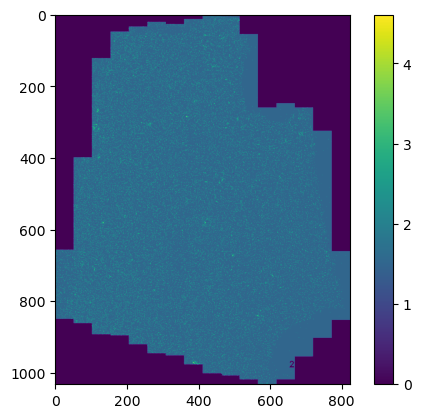

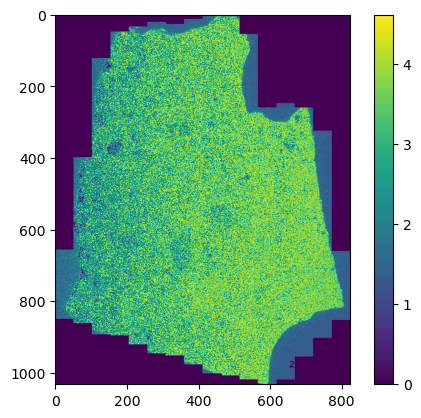

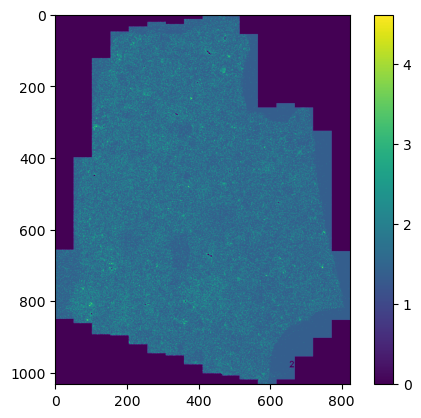

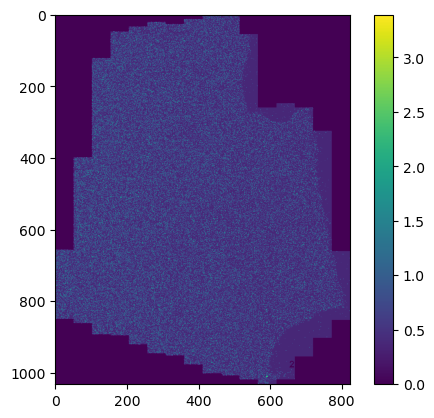

In [ ]:
#for i in range(len(image_names)):
#    plt.figure()
#    plt.imshow(np.log(images_d[i]+1))
#    plt.colorbar()
#    plt.show()